# Operazioni tra insiemi

Oltre alle relazioni descritte nel paragrafo precedente, è possibile costruire
nuovi insiemi a partire da insiemi esistenti utilizzando le operazioni
descritte di seguito.

- L'_unione_ di due insiemi $S$ e $T$ (vedi {numref}`venn-union`) è costituita
  dall'insieme $S \cup T$ contenente tutti gli elementi che appartengono ad
  almeno uno di essi:

$$ S \cup T = \{x \in \Omega | x \in S \vee x \in T \} .$$

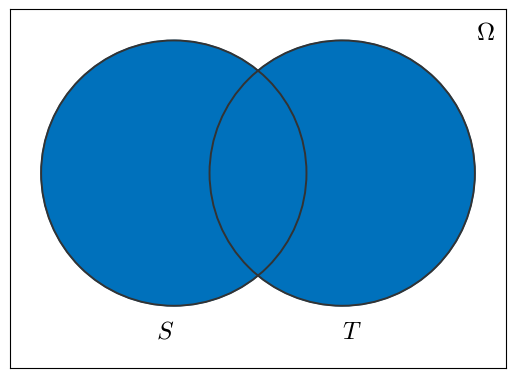

In [1]:
import matplotlib.pyplot as plt
import math
import numpy as np
from matplotlib_venn import venn2_circles, venn2
from myst_nb import glue

import matplotlib
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['mathtext.fontset'] = 'cm'
font_size = 18
matplotlib.rcParams['font.size'] = str(font_size)

venn_set_color = '#0071BC'
venn_set_edge= '#333333'

def venn_operations(operation='union'):
    fig = plt.figure()

    v = venn2(subsets=(3, 3, 1), set_labels=('$S$', '$T$'))
    c = venn2_circles(subsets=(3, 3, 1))

    for l in v.set_labels:
        l.set_fontsize(font_size)

    for contour in c:
        contour.set_lw(1.4)
        contour.set_edgecolor(venn_set_edge)

    for area in ['01', '10', '11']:
        v.get_patch_by_id(area).set_color(venn_set_color)
        v.get_patch_by_id(area).set_alpha(1)
        txt = v.get_label_by_id(area)
        if txt:
            txt.set_text('')

    if operation == 'intersection':
        v.get_patch_by_id('10').set_color('white')
        v.get_patch_by_id('11').set_color(venn_set_color)
        v.get_patch_by_id('11').set_alpha(1)
        v.get_patch_by_id('01').set_color('white')
    elif operation == 'difference':
        v.get_patch_by_id('10').set_color(venn_set_color)
        v.get_patch_by_id('11').set_color('white')
        v.get_patch_by_id('01').set_color('white')
    elif operation == 'symdifference':
        v.get_patch_by_id('11').set_color('white')
    elif operation == 'complement':
        v.get_patch_by_id('10').set_color('white')
        v.get_patch_by_id('11').set_color('white')

    plt.gca().set_facecolor('white' if operation != 'complement' \
                                    else venn_set_color)
    plt.gca().set_axis_on()
    ymin, ymax = plt.gca().get_ylim()
    plt.ylim(ymin - 0.1, ymax)
    plt.text(0.7, 0.43, '$\Omega$')
    return fig

fig = venn_operations('union')
glue("venn-union-picture", fig, display=False)

```{glue:figure} venn-union-picture
:figwidth: 100%
:name: "venn-union"

Un diagramma di Venn per descrivere l'unione degli insiemi $S$ e $T$.
```

- L'_intersezione_ di due insiemi $S$ e $T$ (vedi {numref}`venn-intersection`)
  è costituita dall'insieme $S \cap T$ contenente tutti gli elementi comuni a
  $S$ e $T$:

$$ S \cap T = \{ x \in \Omega | x \in S \wedge x \in T \} .$$

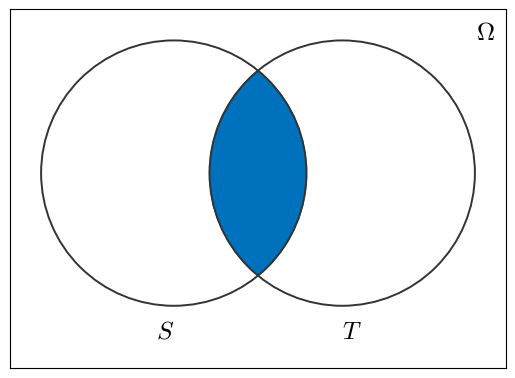

In [2]:
fig = venn_operations('intersection')
glue("venn-intersection-picture", fig, display=False)

```{glue:figure} venn-intersection-picture
:figwidth: 100%
:name: "venn-intersection"

Un diagramma di Venn per descrivere l'intersezione degli insiemi $S$ e $T$.
```

- La _differenza_ tra un insieme $S$ e un insieme $T$ (vedi
  {numref}`venn-difference` è costituita dall'insieme $S \backslash T$
  contenente tutti gli elementi di $S$ che non appartengono a $T$:

$$ S \backslash T = \{ x \in \Omega | x \in S \wedge x \notin T \} .$$

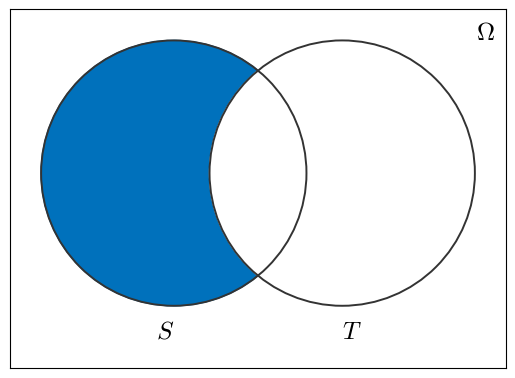

In [3]:
fig = venn_operations('difference')
glue("venn-difference-picture", fig, display=False)

```{glue:figure} venn-difference-picture
:figwidth: 100%
:name: "venn-difference"

Un diagramma di Venn per descrivere la differenza tra l'insieme $S$ e
l'insieme $T$.
```

- La _differenza simmetrica_ tra due insiemi $S$ e $T$ (vedi
  {numref}`venn-symm-difference`) è costituita dall'insieme $S \ominus T$
  contenente tutti gli elementi che appartengono solamente a $S$ o solamente
  a $T$:

$$ S \ominus T = \{ x \in \Omega | ( x \in S \wedge x \notin T )
   \vee ( x \notin S \wedge x \in T) \} .$$

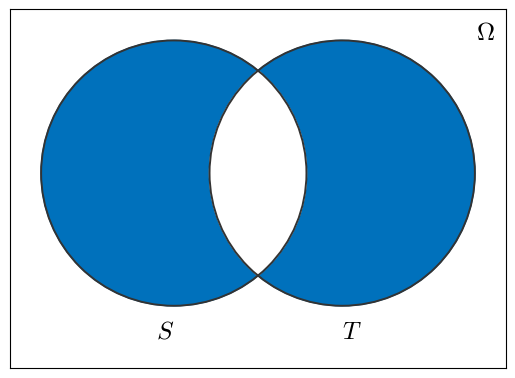

In [4]:
fig = venn_operations('symdifference')
glue("venn-symm-difference-picture", fig, display=False)

```{glue:figure} venn-symm-difference-picture
:figwidth: 100%
:name: "venn-symm-difference"

Un diagramma di Venn per descrivere la differenza simmetrica degli insiemi
$S$ e $T$.
```

- Il _complemento_ di un insieme $S$ è costituito dall'insieme $\overline S$
  (vedi {numref}`venn-complement`) contenente tutti gli elementi dell'insieme
  universo che non appartengono a $S$:

$$ \overline S = \{ x \in \Omega | x \notin S \} = \Omega \backslash S. $$

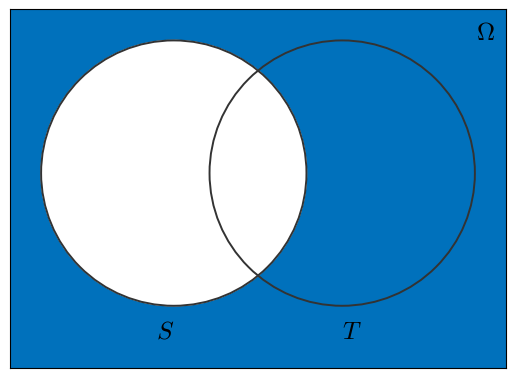

In [5]:
fig = venn_operations('complement')
glue("venn-complement-picture", fig, display=False)

```{glue:figure} venn-complement-picture
:figwidth: 100%
:name: "venn-complement"

Un diagramma di Venn per descrivere il complemento dell'insieme $S$.
```

Si verifica facilmente come le operazioni di unione e intersezione siano

- commutative: vale sempre $S \cup T = T \cup S$ e $S \cap T = T \cap S$, e
  quindi è possibile invertire due insiemi senza che cambino la loro unione o
  la loro intersezione;
- associative: $S \cup ( T \cup U ) = (S \cup T ) \cup U$ e
  $S \cap ( T \cap U ) = (S \cap T ) \cap U$, il che significa che l'ordine con
  cui vengono eseguite due unioni (o due intersezioni) è ininfluente, pertanto
  è possibile scrivere per esempio $S \cup T \cup U$ senza che l'espressione
  risultante sia ambigua.

Valgono inoltre le cosiddette _leggi di De Morgan_:

1. $\overline{\left( S \cup T \right)} = \overline S \cap \overline T$;
1. $\overline{\left( S \cap T \right)} = \overline S \cup \overline T$.

Le leggi di De Morgan ci dicono essenzialmente che è possibile "trasferire"
l'operazione di complemento dall'unione di due insiemi ai due insiemi stessi,
avendo cura di convertire l'uione in intersezione (e un'analoga operazione vale
per il complemento di un'intersezione). Dimostriamo la prima delle due leggi:
se $x \in \overline{\left( S \cup T \right)}$, per definizione di complemento
$x \notin \left( S \cup T \right)$, il che implica $x \notin S$ e $x \notin T$.
Da questo fatto si ottiene, sempre sfruttando la definizione di complemento,
che $x \in \overline S$ e $x \in \overline T$, e dunque
$x \in \overline S \cap \overline T$. Siccome non abbiamo fatto particolari
ipotesi su $x$ se non quella che fosse un elemento di $S$, abbiamo dunque
dimostrato che
$\overline{\left( S \cup T \right)} \subseteq \overline S \cap \overline T$.
Procedendo in modo inverso (cioè partendo da
$x \in \overline S \cap \overline T$) si può dimostrare che
$\overline S \cap \overline T \subseteq \overline{\left( S \cup T \right)}$,
ottenendo pertanto la prima legge di De Morgan. Un'analoga dimostrazione
permette di ottenere la seconda legge.

Valgono, infine, le seguenti relazioni tra la differenza simmetrica, l'unione,
l'intersezione e la differenza tra insiemi:

1. $S \ominus T = (S \backslash T) \cup (T \backslash S)$,
1. $S \ominus T = (S \cup T) \backslash (S \cap T)$.

Guardando il diagramma di Venn della {numref}`venn-symm-difference` è facile
convincersi della validità di queste due uguaglianze. Dimostriamo parzialmente
la seconda ipotizzando valida la prima, adottando la stessa tecnica utilizzata
per le leggi di De Morgan: se $x \in (S \cup T) \backslash (S \cap T)$, allora
$x \in (S \cup T)$ e $x \notin (S \cap T)$, il che implica
$(x \in S \vee x \in T) \wedge (x \notin S \cap T)$. Per la distribuzione della
disgiunzione sulla congiunzione si ottiene
$(x \in S \wedge x \notin S \cap T) \vee (x \in T \wedge x \notin S \cap T)$.
Pertanto $x \in S \backslash T \vee x \in T \backslash S$, e assumendo vera la
prima delle due relazioni si ottiene $x \in S \ominus T$.